In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
import cv2
import gc
import seaborn as sns
from torchviz import make_dot

In [3]:
DATASET_PATH = "./dataset"
batch_size = 16
# Not really 200, early stopping will take care of it.
num_epochs = 200
learning_rate = 0.0001

In [4]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [5]:
def load_dataset(dataset_path, image_size=(128, 128), rgb=False):
    dataset_path = Path(dataset_path)
    class_names = sorted(path.name for path in dataset_path.iterdir() if path.is_dir())
    class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
    images = []
    labels = []
    for class_name in class_names:
        class_dir = dataset_path / class_name
        for image_path in sorted(class_dir.glob("*.jpg")):
            if rgb:
                image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
            else:
                image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
            if image is None:
                continue
            # Crop the data not important
            image = image[282:1517, 70:2173]
            if rgb:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, image_size)
            images.append(image)
            labels.append(class_to_idx[class_name])
    return np.array(images), np.array(labels), np.array(class_names), class_to_idx

In [6]:
images, labels, class_names, class_to_idx = load_dataset(DATASET_PATH, (224, 224), False)

# Used for pretrained RGB models
images_rgb, labels_rgb, class_names_rgb, class_to_idx_rgb = load_dataset(DATASET_PATH, (224, 224), True)

In [7]:
print(f"Loaded {len(images)} images")
print(f"Image tensor shape: {tuple(images.shape)}")
print(f"Classes: {class_names}")

Loaded 928 images
Image tensor shape: (928, 224, 224)
Classes: ['AHB' 'HMI' 'MI' 'Normal']


In [8]:
print(f"Loaded {len(images_rgb)} images")
print(f"Image tensor shape: {tuple(images_rgb.shape)}")
print(f"Classes: {class_names_rgb}")

Loaded 928 images
Image tensor shape: (928, 224, 224, 3)
Classes: ['AHB' 'HMI' 'MI' 'Normal']


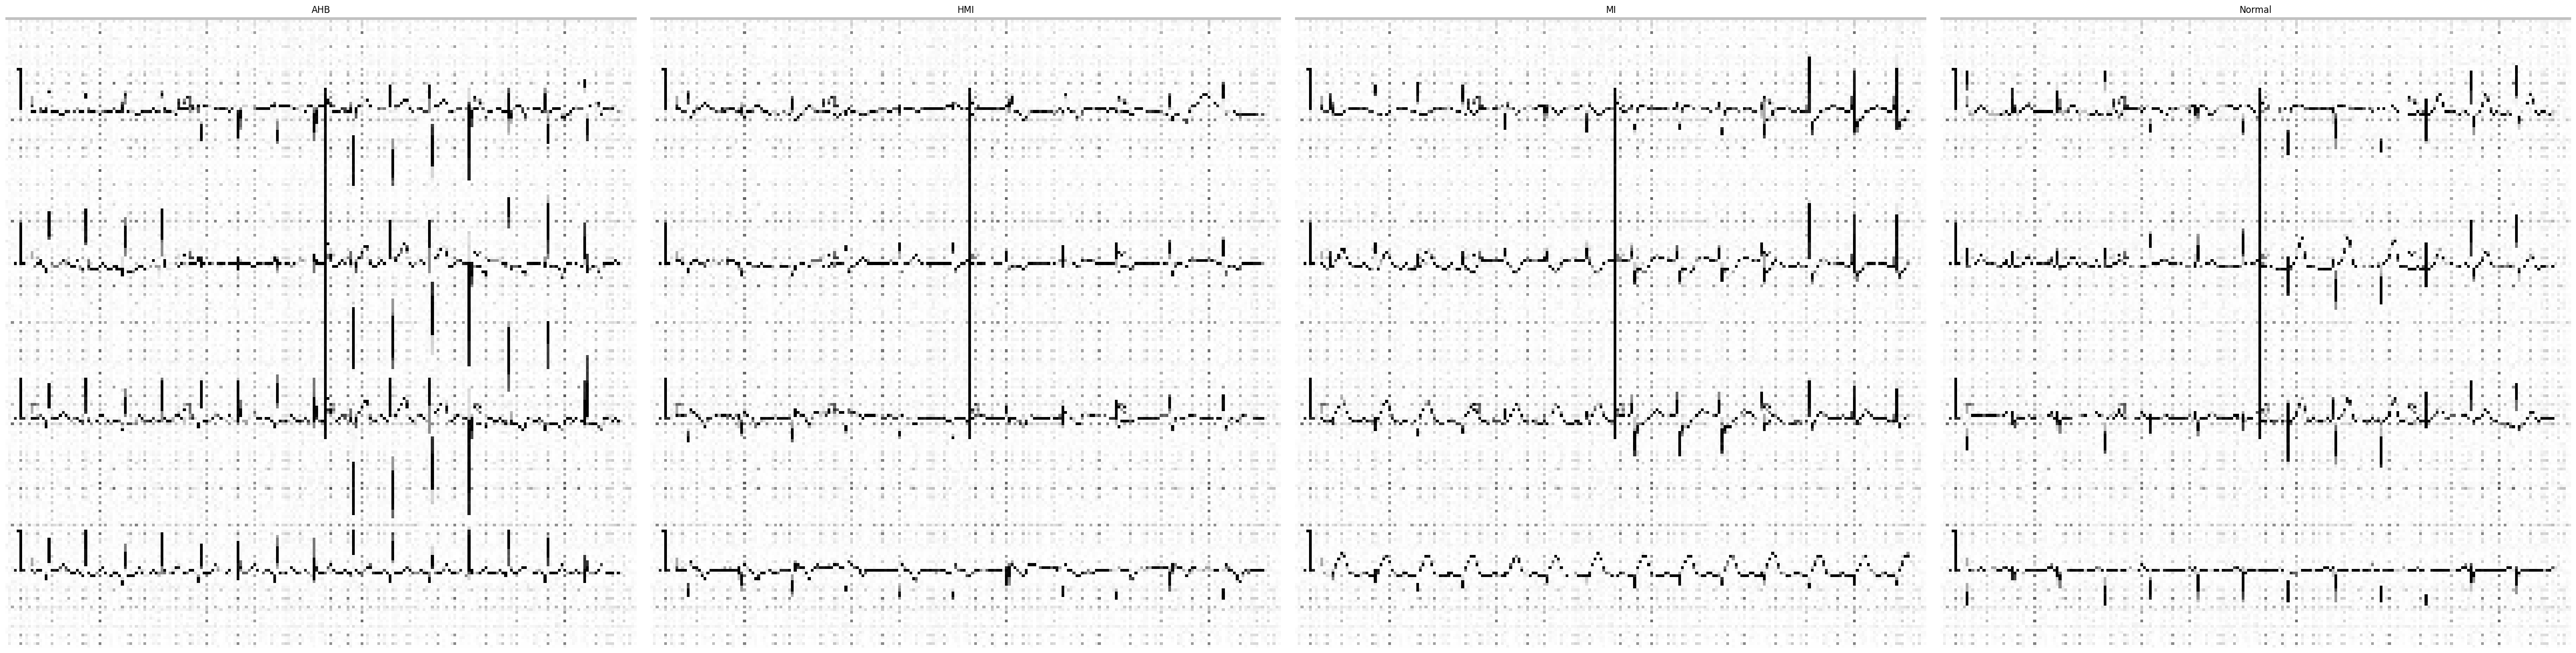

In [9]:
# Display sample images from each class
fig, axes = plt.subplots(1, len(class_names), figsize=(12 * len(class_names), 12))
for idx, class_name in enumerate(class_names):
    sample_index = np.where(labels == idx)[0][0]
    axes[idx].imshow(images[sample_index], cmap="gray")
    axes[idx].set_title(class_name)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

AHB: 233 images
HMI: 172 images
MI: 239 images
Normal: 284 images


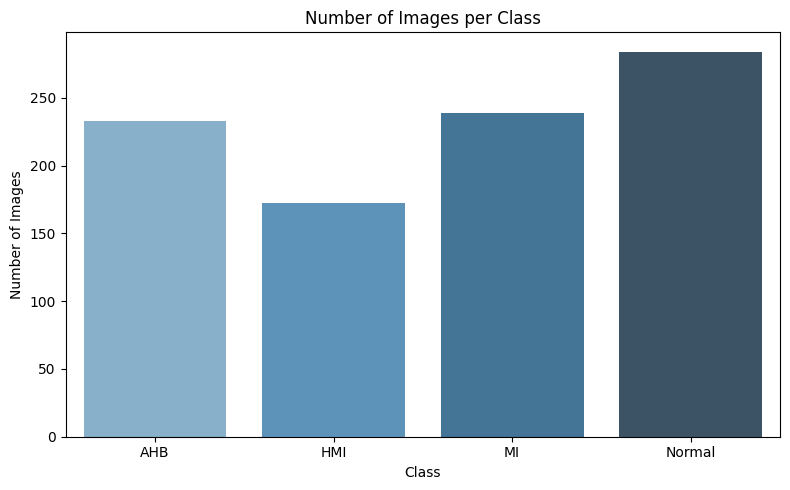

In [10]:
class_counts = {class_name: int(np.sum(labels == idx)) for idx, class_name in enumerate(class_names)}
for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")

plt.figure(figsize=(8, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), hue=list(class_counts.keys()), palette='Blues_d', legend=False)
plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

In [11]:
# Define transforms with augmentation for training
train_transform = transforms.Compose([
    transforms.ToPILImage(),  # Convert numpy to PIL for augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_transform_rgb = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

# No augmentation for validation/test
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

val_transform_rgb = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

In [12]:
class ECGDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        label = self.labels[idx]

        if self.transform:
            sample = self.transform(sample)

        return sample, label

In [13]:
# Split the dataset into training, test, and validation sets
X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.2, random_state=42, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

X_train_rgb, X_temp_rgb, y_train_rgb, y_temp_rgb = train_test_split(images_rgb, labels_rgb, test_size=0.2, random_state=42, stratify=labels_rgb)
X_val_rgb, X_test_rgb, y_val_rgb, y_test_rgb = train_test_split(X_temp_rgb, y_temp_rgb, test_size=0.5, random_state=42, stratify=y_temp_rgb)

In [14]:
# Create dataset
train_dataset = ECGDataset(X_train, y_train, transform=train_transform)
val_dataset = ECGDataset(X_val, y_val, transform=val_transform)
test_dataset = ECGDataset(X_test, y_test, transform=val_transform)

train_dataset_rgb = ECGDataset(X_train_rgb, y_train_rgb, transform=train_transform_rgb)
val_dataset_rgb = ECGDataset(X_val_rgb, y_val_rgb, transform=val_transform_rgb)
test_dataset_rgb = ECGDataset(X_test_rgb, y_test_rgb, transform=val_transform_rgb)

In [15]:
# Weighted random samplers
class_sample_count = torch.tensor([(y_train == t).sum() for t in np.unique(y_train)])
weight = 1. / class_sample_count.float()
samples_weight = torch.tensor([weight[t] for t in torch.tensor(y_train)])
sampler = torch.utils.data.WeightedRandomSampler(samples_weight, len(samples_weight), replacement=True)

class_sample_count_rgb = torch.tensor([(y_train_rgb == t).sum() for t in np.unique(y_train_rgb)])
weight_rgb = 1. / class_sample_count_rgb.float()
samples_weight_rgb = torch.tensor([weight_rgb[t] for t in torch.tensor(y_train_rgb)])
sampler_rgb = torch.utils.data.WeightedRandomSampler(samples_weight_rgb, len(samples_weight_rgb), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, drop_last=False)

train_loader_rgb = DataLoader(train_dataset_rgb, batch_size=batch_size, sampler=sampler_rgb, drop_last=True)
val_loader_rgb = DataLoader(val_dataset_rgb, batch_size=batch_size, drop_last=False)
test_loader_rgb = DataLoader(test_dataset_rgb, batch_size=batch_size, drop_last=False)

### Model Setup

In [16]:
resnet = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in resnet.parameters():
    param.requires_grad = False

for param in resnet.layer2.parameters():
    param.requires_grad = True

for param in resnet.layer3.parameters():
    param.requires_grad = True

for param in resnet.layer4.parameters():
    param.requires_grad = True

resnet_num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(resnet_num_ftrs, len(class_names))
resnet_criterion = nn.CrossEntropyLoss()
resnet_optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet.parameters()), lr=learning_rate)
resnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(resnet_optimizer, mode='min', factor=0.5, patience=5)

In [17]:
densenet = torchvision.models.densenet121(weights='IMAGENET1K_V1')
for param in densenet.parameters():
    param.requires_grad = False

for param in densenet.features.denseblock2.parameters():
    param.requires_grad = True

for param in densenet.features.denseblock3.parameters():
    param.requires_grad = True

for param in densenet.features.denseblock4.parameters():
    param.requires_grad = True

densenet_num_ftrs = densenet.classifier.in_features
densenet.classifier = nn.Linear(densenet_num_ftrs, len(class_names))
densenet_criterion = nn.CrossEntropyLoss()
densenet_optimizer = optim.Adam(filter(lambda p: p.requires_grad, densenet.parameters()), lr=learning_rate)
densenet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(densenet_optimizer, mode='min', factor=0.5, patience=5)

In [18]:
efficientnet = torchvision.models.efficientnet_b0(weights='IMAGENET1K_V1')
for param in efficientnet.parameters():
    param.requires_grad = False

for param in efficientnet.features[-2].parameters():
    param.requires_grad = True

for param in efficientnet.features[-3].parameters():
    param.requires_grad = True

for param in efficientnet.features[-4].parameters():
    param.requires_grad = True

for param in efficientnet.features[-5].parameters():
    param.requires_grad = True

for param in efficientnet.classifier.parameters():
    param.requires_grad = True

efficientnet_num_ftrs = efficientnet.classifier[1].in_features
efficientnet.classifier[1] = nn.Linear(efficientnet_num_ftrs, len(class_names))
efficientnet_criterion = nn.CrossEntropyLoss()
efficientnet_optimizer = optim.Adam(filter(lambda p: p.requires_grad, efficientnet.parameters()), lr=learning_rate)
efficientnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(efficientnet_optimizer, mode='min', factor=0.5, patience=5)

In [19]:
convnext = torchvision.models.convnext_tiny(weights='IMAGENET1K_V1')
for param in convnext.parameters():
    param.requires_grad = False

for param in convnext.features[-1].parameters():
    param.requires_grad = True

for param in convnext.features[-3].parameters():
    param.requires_grad = True

for param in convnext.features[-5].parameters():
    param.requires_grad = True

for param in convnext.classifier.parameters():
    param.requires_grad = True

convnext_num_ftrs = convnext.classifier[2].in_features
convnext.classifier[2] = nn.Linear(convnext_num_ftrs, len(class_names))
convnext_criterion = nn.CrossEntropyLoss()
convnext_optimizer = optim.Adam(filter(lambda p: p.requires_grad, convnext.parameters()), lr=learning_rate)
convnext_scheduler = optim.lr_scheduler.ReduceLROnPlateau(convnext_optimizer, mode='min', factor=0.5, patience=5)

In [20]:
alexnet = torchvision.models.alexnet(weights='IMAGENET1K_V1')
for param in alexnet.parameters():
    param.requires_grad = False

for param in alexnet.features[-3].parameters():
    param.requires_grad = True

for param in alexnet.features[-5].parameters():
    param.requires_grad = True

for param in alexnet.features[-7].parameters():
    param.requires_grad = True

for param in alexnet.features[-10].parameters():
    param.requires_grad = True

for param in alexnet.classifier.parameters():
    param.requires_grad = True

alexnet_num_ftrs = alexnet.classifier[-1].in_features
alexnet.classifier[-1] = nn.Linear(alexnet_num_ftrs, len(class_names))
alexnet_criterion = nn.CrossEntropyLoss()
alexnet_optimizer = optim.Adam(filter(lambda p: p.requires_grad, alexnet.parameters()), lr=learning_rate)
alexnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(alexnet_optimizer, mode='min', factor=0.5, patience=5)

### Custom ConvNet

In [21]:
class ConvNet(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(ConvNet, self).__init__()
        # First conv block
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)

        # Second conv block
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)

        # Third conv block
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)

        # Fourth conv block
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout2d = nn.Dropout2d(p=0.4)

        # Fully connected layers
        self.fc1 = nn.Linear(512 * 14 * 14, 512)
        self.bn5 = nn.BatchNorm1d(512)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc2 = nn.Linear(512, len(class_to_idx))

    def forward(self, x):
        # Block 1: 224x224 -> 112x112
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)

        # Block 2: 112x112 -> 56x56
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)

        # Block 3: 56x56 -> 28x28
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool(x)
        x = self.dropout2d(x)

        # Block 4: 28x28 -> 14x14
        x = self.conv4(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.pool(x)
        x = self.dropout2d(x)

        # Fully connected
        x = torch.flatten(x, start_dim=1)
        x = self.fc1(x)
        x = self.bn5(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [22]:
net = ConvNet()
net_criterion = nn.CrossEntropyLoss()
net_optimizer = optim.Adam(net.parameters(), lr=learning_rate)
net_scheduler = optim.lr_scheduler.ReduceLROnPlateau(net_optimizer, mode='min', factor=0.5, patience=5)

### Shared Training and Evaluation

In [23]:
def cleanup_gpu(model=None, optimizer=None):
    if optimizer is not None:
        for state in optimizer.state.values():
            for key, value in state.items():
                if torch.is_tensor(value):
                    state[key] = value.cpu()

    if model is not None:
        model.cpu()

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def train_models(model_configs, training_config):
    training_results = {}
    num_epochs = training_config['num_epochs']
    patience = training_config['patience']
    device = training_config['device']
    verbose = training_config.get('verbose', True)

    # Keep every model on CPU until its turn to train.
    for config in model_configs.values():
        config['model'].cpu()
    cleanup_gpu()

    for model_name, config in model_configs.items():
        model = config['model'].to(device)
        criterion = config['criterion']
        optimizer = config['optimizer']
        scheduler = config['scheduler']
        train_loader = config['train_loader']
        val_loader = config['val_loader']
        checkpoint_path = config['checkpoint_path']
        display_name = config['display_name']

        best_val_loss = float('inf')
        best_epoch = 0
        patience_counter = 0
        loss_history = []
        val_loss_history = []

        if verbose:
            print(f'Training {display_name}')

        try:
            for epoch in range(num_epochs):
                model.train()
                epoch_loss = 0.0
                num_batches = 0

                for inputs, labels in train_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    optimizer.zero_grad(set_to_none=True)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()

                    epoch_loss += loss.item()
                    num_batches += 1

                avg_epoch_loss = epoch_loss / num_batches if num_batches > 0 else 0.0

                model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for inputs, labels in val_loader:
                        inputs, labels = inputs.to(device), labels.to(device)
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                        val_loss += loss.item()

                avg_val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else 0.0

                if scheduler is not None:
                    scheduler.step(avg_val_loss)

                if verbose:
                    print(f'Epoch [{epoch+1}/{num_epochs}]')
                    print(f'  Training Loss:   {avg_epoch_loss:.4f}')
                    print(f'  Validation Loss: {avg_val_loss:.4f}')
                    print(f'  Learning Rate:   {optimizer.param_groups[0]["lr"]:.6f}')
                    print('-' * 50)

                loss_history.append(avg_epoch_loss)
                val_loss_history.append(avg_val_loss)

                if avg_val_loss < best_val_loss:
                    best_val_loss = avg_val_loss
                    best_epoch = epoch + 1
                    patience_counter = 0
                    torch.save(model.state_dict(), checkpoint_path)
                    if verbose:
                        print('Best model saved!')
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        if verbose:
                            print(f'\nEarly stopping triggered after {epoch+1} epochs')
                        break
        finally:
            cleanup_gpu(model=model, optimizer=optimizer)

        if verbose:
            print('\nFinished Training')
            print(f'Best Validation Loss: {best_val_loss:.4f}')

        training_results[model_name] = {
            'display_name': display_name,
            'loss_history': loss_history,
            'val_loss_history': val_loss_history,
            'best_val_loss': best_val_loss,
            'best_epoch': best_epoch,
            'checkpoint_path': checkpoint_path,
        }

    return training_results


def load_best_models(model_configs, device='cpu'):
    for config in model_configs.values():
        model = config['model']
        state_dict = torch.load(config['checkpoint_path'], map_location=device)
        model.load_state_dict(state_dict)
        model.to(device)


def evaluate_models(model_configs, device=None):
    evaluation_results = {}
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    for model_name, config in model_configs.items():
        model = config['model'].to(device)
        test_loader = config['test_loader']
        display_name = config['display_name']

        state_dict = torch.load(config['checkpoint_path'], map_location=device)
        model.load_state_dict(state_dict)
        model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        test_accuracy = 100 * correct / total if total > 0 else 0.0
        cm = confusion_matrix(all_labels, all_predictions)
        report = classification_report(all_labels, all_predictions, output_dict=True, zero_division=0)
        print(f'{display_name} Test Accuracy: {test_accuracy:.2f}%')

        evaluation_results[model_name] = {
            'display_name': display_name,
            'test_accuracy': test_accuracy,
            'all_predictions': all_predictions,
            'all_labels': all_labels,
            'confusion_matrix': cm,
            'classification_report': report,
        }

        cleanup_gpu(model=model)

    return evaluation_results

In [24]:
def plot_all_losses(training_results):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    for result in training_results.values():
        epochs = list(range(1, len(result['loss_history']) + 1))
        axes[0].plot(epochs, result['loss_history'], marker='o', label=result['display_name'])
        axes[1].plot(epochs, result['val_loss_history'], marker='o', label=result['display_name'])

    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].set_title('Validation Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_test_accuracies(evaluation_results):
    model_names = [result['display_name'] for result in evaluation_results.values()]
    accuracies = [result['test_accuracy'] for result in evaluation_results.values()]

    plt.figure(figsize=(12, 6))
    bars = plt.bar(model_names, accuracies, color=sns.color_palette('deep', n_colors=len(model_names)))
    plt.title('Test Accuracy Comparison')
    plt.xlabel('Model')
    plt.ylabel('Accuracy (%)')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, max(accuracies) * 1.1 if accuracies else 1)

    for bar, accuracy in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{accuracy:.2f}%', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()


def plot_all_confusion_matrices(evaluation_results, class_to_idx):
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    class_names = [idx_to_class[i] for i in range(len(class_to_idx))]
    n_models = len(evaluation_results)
    ncols = 2
    nrows = int(np.ceil(n_models / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
    axes = np.array(axes, dtype=object).reshape(-1)

    for ax, result in zip(axes, evaluation_results.values()):
        sns.heatmap(
            result['confusion_matrix'],
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=False,
            ax=ax,
        )
        ax.set_title(result['display_name'])
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')

    for ax in axes[n_models:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [25]:
training_config = {
    'num_epochs': num_epochs,
    'patience': 15,
    'device': device,
    'verbose': True,
}

model_configs = {
    'resnet': {
        'display_name': 'ResNet18',
        'model': resnet,
        'criterion': resnet_criterion,
        'optimizer': resnet_optimizer,
        'scheduler': resnet_scheduler,
        'train_loader': train_loader_rgb,
        'val_loader': val_loader_rgb,
        'test_loader': test_loader_rgb,
        'checkpoint_path': 'best_model_resnet.pth',
    },
    'densenet': {
        'display_name': 'DenseNet121',
        'model': densenet,
        'criterion': densenet_criterion,
        'optimizer': densenet_optimizer,
        'scheduler': densenet_scheduler,
        'train_loader': train_loader_rgb,
        'val_loader': val_loader_rgb,
        'test_loader': test_loader_rgb,
        'checkpoint_path': 'best_model_densenet.pth',
    },
    'efficientnet': {
        'display_name': 'EfficientNet-B0',
        'model': efficientnet,
        'criterion': efficientnet_criterion,
        'optimizer': efficientnet_optimizer,
        'scheduler': efficientnet_scheduler,
        'train_loader': train_loader_rgb,
        'val_loader': val_loader_rgb,
        'test_loader': test_loader_rgb,
        'checkpoint_path': 'best_model_efficientnet.pth',
    },
    'convnext': {
        'display_name': 'ConvNeXt-Tiny',
        'model': convnext,
        'criterion': convnext_criterion,
        'optimizer': convnext_optimizer,
        'scheduler': convnext_scheduler,
        'train_loader': train_loader_rgb,
        'val_loader': val_loader_rgb,
        'test_loader': test_loader_rgb,
        'checkpoint_path': 'best_model_convnext.pth',
    },
    'alexnet': {
        'display_name': 'AlexNet',
        'model': alexnet,
        'criterion': alexnet_criterion,
        'optimizer': alexnet_optimizer,
        'scheduler': alexnet_scheduler,
        'train_loader': train_loader_rgb,
        'val_loader': val_loader_rgb,
        'test_loader': test_loader_rgb,
        'checkpoint_path': 'best_model_alexnet.pth',
    },
    'custom_convnet': {
        'display_name': 'Custom ConvNet',
        'model': net,
        'criterion': net_criterion,
        'optimizer': net_optimizer,
        'scheduler': net_scheduler,
        'train_loader': train_loader,
        'val_loader': val_loader,
        'test_loader': test_loader,
        'checkpoint_path': 'best_model.pth',
    },
}

In [26]:
training_results = train_models(model_configs, training_config)

Training ResNet18
Epoch [1/200]
  Training Loss:   1.1452
  Validation Loss: 1.1302
  Learning Rate:   0.000100
--------------------------------------------------
Best model saved!
Epoch [2/200]
  Training Loss:   0.8100
  Validation Loss: 0.8145
  Learning Rate:   0.000100
--------------------------------------------------
Best model saved!
Epoch [3/200]
  Training Loss:   0.6134
  Validation Loss: 0.4149
  Learning Rate:   0.000100
--------------------------------------------------
Best model saved!
Epoch [4/200]
  Training Loss:   0.4710
  Validation Loss: 0.4669
  Learning Rate:   0.000100
--------------------------------------------------
Epoch [5/200]
  Training Loss:   0.4644
  Validation Loss: 0.4540
  Learning Rate:   0.000100
--------------------------------------------------
Epoch [6/200]
  Training Loss:   0.3713
  Validation Loss: 0.4816
  Learning Rate:   0.000100
--------------------------------------------------
Epoch [7/200]
  Training Loss:   0.3896
  Validation Loss:

ResNet18 Test Accuracy: 95.70%
DenseNet121 Test Accuracy: 97.85%
EfficientNet-B0 Test Accuracy: 92.47%
ConvNeXt-Tiny Test Accuracy: 92.47%
AlexNet Test Accuracy: 87.10%
Custom ConvNet Test Accuracy: 95.70%


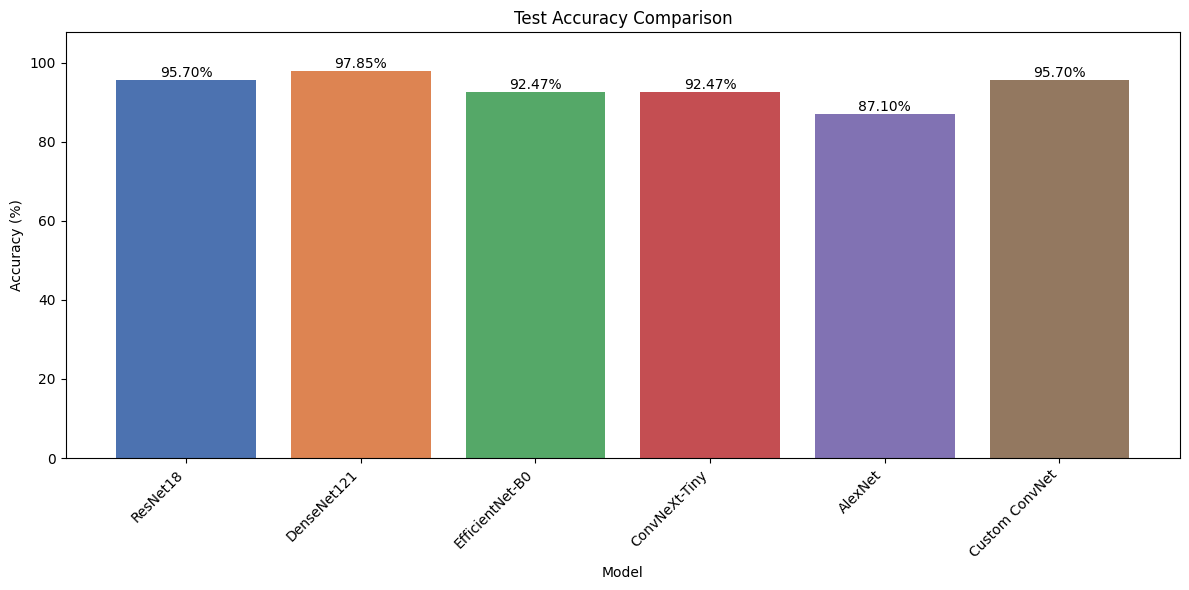


=== ResNet18 ===
              precision    recall  f1-score   support

         AHB       0.86      1.00      0.92        24
         HMI       1.00      0.88      0.94        17
          MI       1.00      1.00      1.00        24
      Normal       1.00      0.93      0.96        28

    accuracy                           0.96        93
   macro avg       0.96      0.95      0.96        93
weighted avg       0.96      0.96      0.96        93


=== DenseNet121 ===
              precision    recall  f1-score   support

         AHB       1.00      0.92      0.96        24
         HMI       0.94      1.00      0.97        17
          MI       1.00      1.00      1.00        24
      Normal       0.97      1.00      0.98        28

    accuracy                           0.98        93
   macro avg       0.98      0.98      0.98        93
weighted avg       0.98      0.98      0.98        93


=== EfficientNet-B0 ===
              precision    recall  f1-score   support

         AH

In [27]:
evaluation_results = evaluate_models(model_configs, device)
plot_test_accuracies(evaluation_results)

for model_name, result in evaluation_results.items():
    print(f"\n=== {result['display_name']} ===")
    print(classification_report(
        result['all_labels'],
        result['all_predictions'],
        target_names=class_names,
        zero_division=0,
    ))


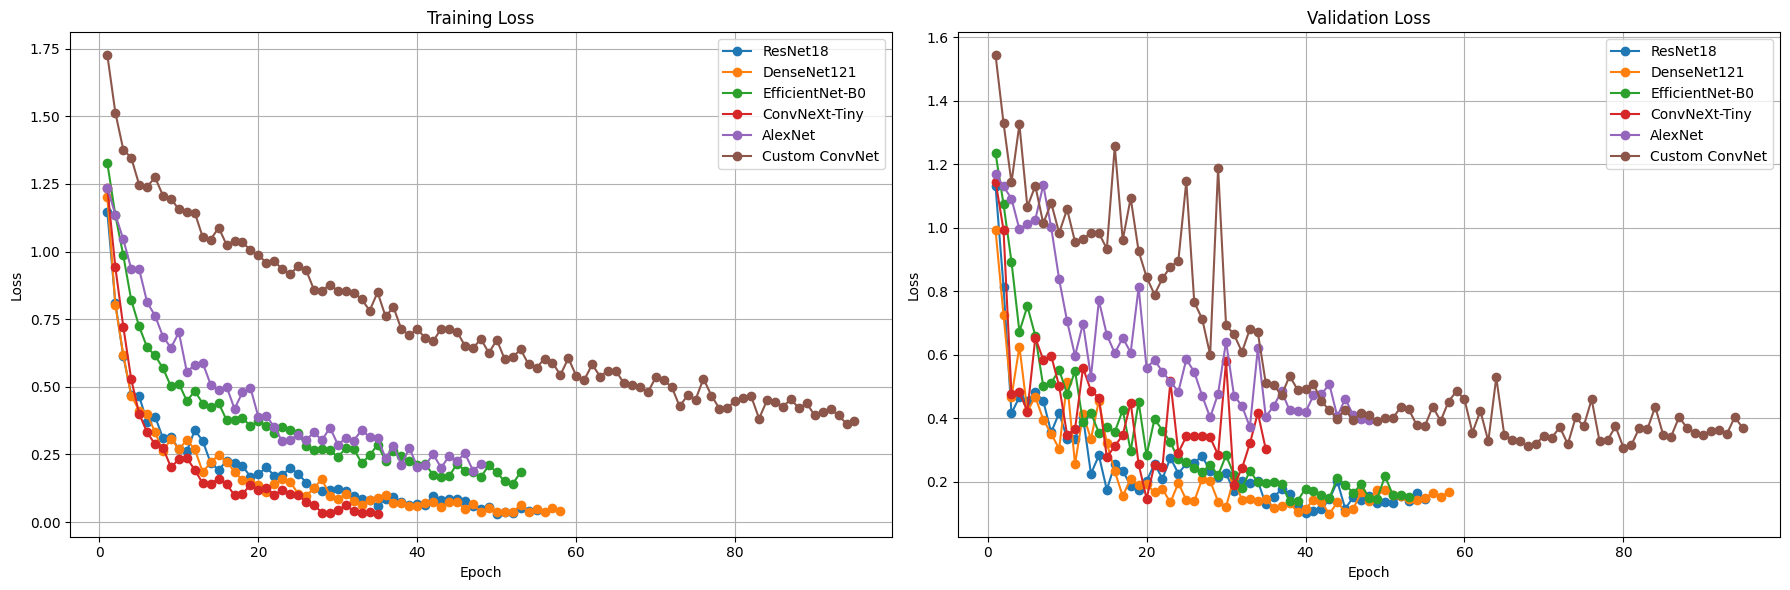

In [28]:
plot_all_losses(training_results)

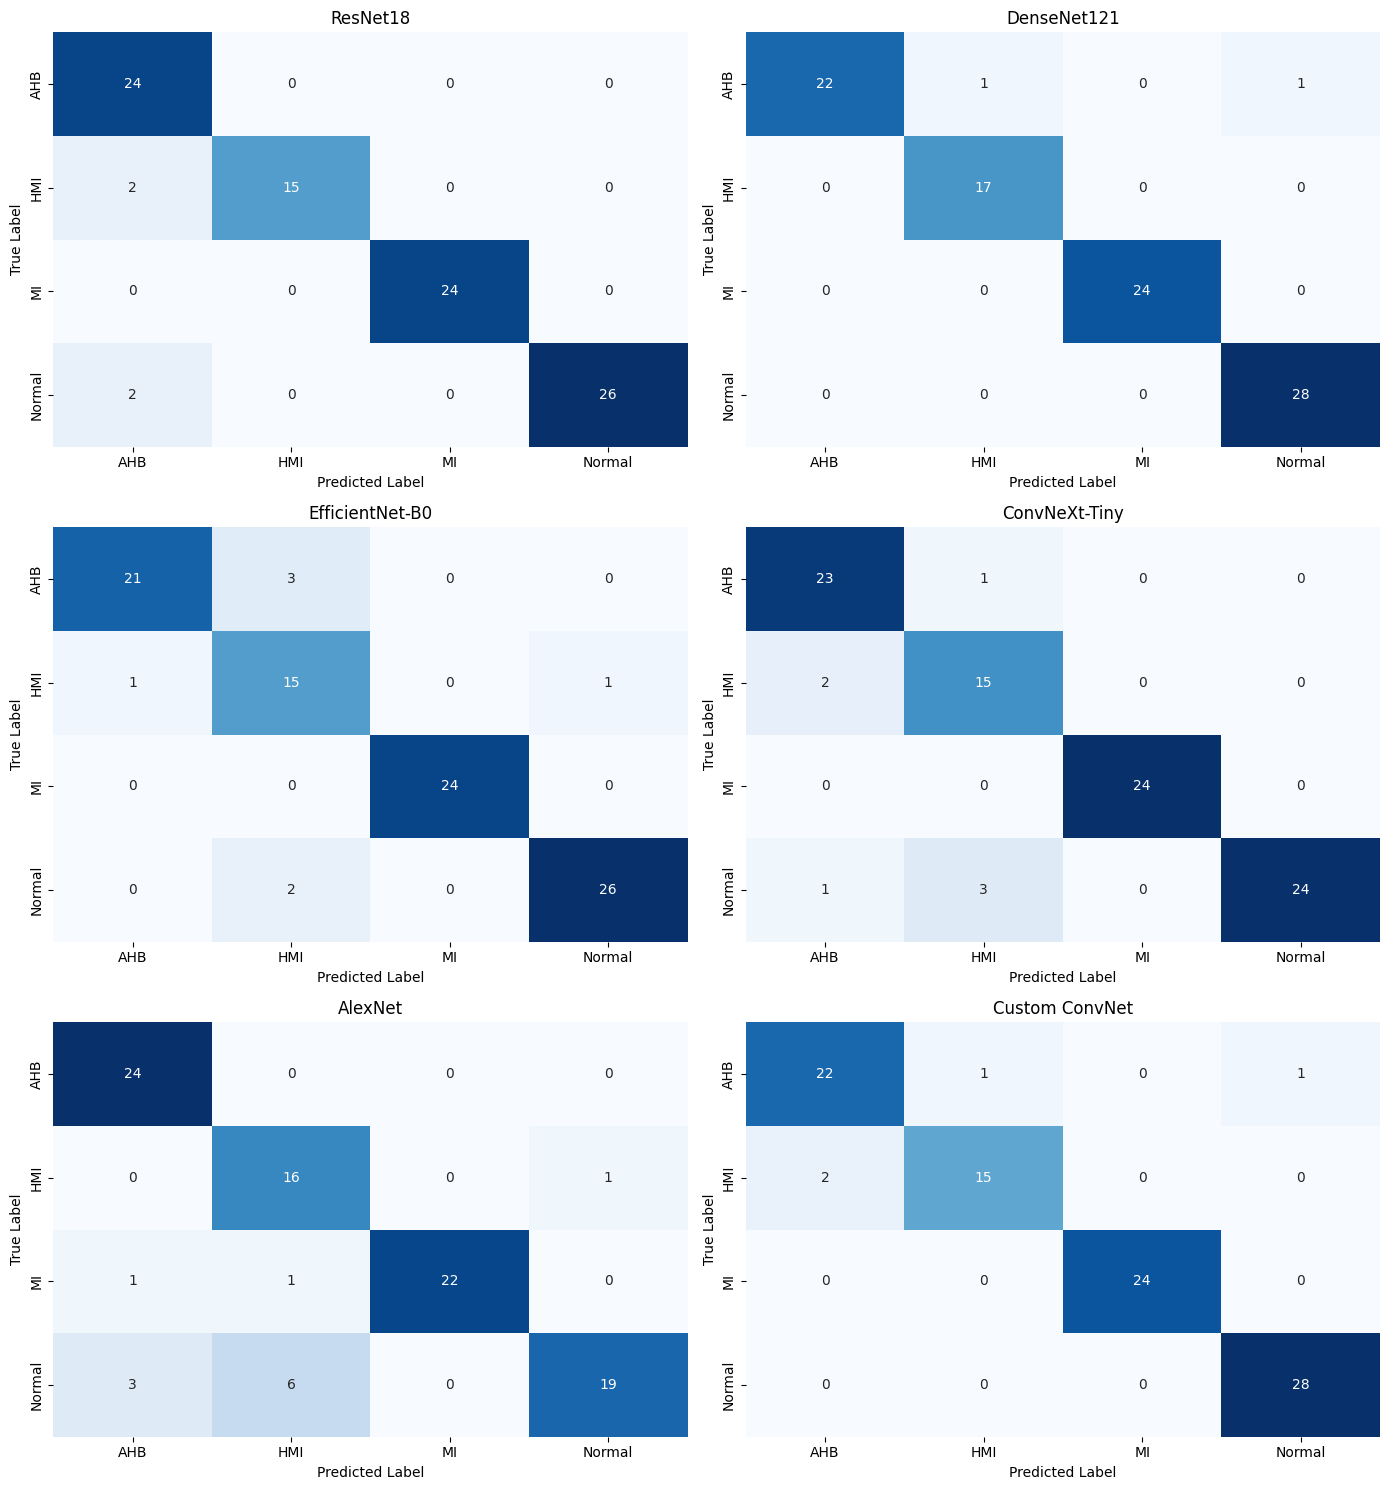

In [29]:
plot_all_confusion_matrices(evaluation_results, class_to_idx)

In [35]:
custom_convnet = ConvNet()
custom_convnet.eval()
x = torch.zeros(1, 1, 224, 224)
y = custom_convnet(x)
dot = make_dot(y, params=dict(custom_convnet.named_parameters()), show_attrs=False, show_saved=False)
dot.attr(rankdir='TB')
dot.render('custom_convnet_graph', format='png', cleanup=True)
print('Saved custom_convnet_graph.png')

Saved custom_convnet_graph.png


In [37]:
torch.onnx.export(
    custom_convnet,
    x,
    'convnet.onnx',
    input_names=['input'],
    output_names=['output'],
)

[torch.onnx] Obtain model graph for `ConvNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ConvNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.11.0+cu130',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,1,224,224]>
            ),
            outputs=(
                %"output"<FLOAT,[1,4]>
            ),
            initializers=(
                %"conv1.weight"<FLOAT,[64,1,3,3]>{Tensor(...)},
                %"conv1.bias"<FLOAT,[64]>{Tensor(...)},
                %"conv2.weight"<FLOAT,[128,64,3,3]>{Tensor(...)},
                %"conv2.bias"<FLOAT,[128]>{Tensor(...)},
                %"conv3.weight"<FLOAT,[256,128,3,3]>{Tensor(...)},
                %"conv3.bias"<FLOAT,[256]>{Tensor(...)},
                %"conv4.weight"<FLOAT,[512,256,3,3]>{Tensor(...)},
                %"conv4.bias"<FLOAT,[512]>{Tensor(...)},
                %"fc1.weight"<FLOA